# C++的模板

# 1. 模板简介

① C++的一种编程思想称为泛型编程，主要利用的技术就是模板。

② 模板就是建立通用的模具，大大提高复用性。

③ 模板的特点：

1. 模板不可以直接使用，它只是一个框架。
2. 模板的通用并不是万能的。

④ C++提供两种模板机制：函数模板和类模板。

总结:
·利用具体化的模板，可以解决自定义类型的通用化
·学习模板并不是为了写模板，而是在STL能够运用系统提供的模板

# 2. 函数模板

## 2.1 函数模板基本语法

① 函数模板作用：建立一个通用函数，其函数返回值类型和形参类型可以不具体制定，用一个虚拟的类型来代表。

② 函数模板利用关键字 template。

③ 函数模板声明或定义为 template<typename T>

1. template -- 声明创建模板
2. typename -- 表明其后面的符号是一种数据类型，可以用class代替
3. T -- 通用的数据类型，名称可以替换，通常为大写字母

④ 使用函数模板有两种方式，自动类型推导、显示指定类型。

⑤ 模板的目的是为了提高复用性，将类型也参数化。

In [ ]:
#include <iostream>
using namespace std;

//函数模板

//两个整型交换函数
void swapInt(int& a, int& b)
{
    int temp = a;
    a = b;
    b = temp;
}

//两个浮点型交换函数
void swapDouble(double &a, double &b)
{
    double temp = a;
    a = b;
    b = temp;
}

//函数模板
template<typename T> //声明一个模板，告诉编译器后面代码中紧跟着的T不要报错，T是一个通用数据类型
void mySwap( T &a, T &b)
{
    T temp = a;
    a = b;
    b = temp;
}

void test01()
{
    int a = 10;
    int b = 20;

    swapInt(a, b);
    cout << "a= " << a << endl;
    cout << "b= " << b << endl;

    double c = 1.1;
    double d = 2.2;
    swapDouble(c, d);
    cout << "c= " << c << endl;
    cout << "d= " << d << endl;
}

void test02()
{
    int m = 10;
    int n = 20;
    //利用函数模板交换
    //两种方式使用函数模板
    //1、自动类型推导
    mySwap(m,n); //根据m、n的数据为int，自动设置为T为int
    cout << "m= " << m << endl;
    cout << "n= " << n << endl;

    //2、显示指定类型
    mySwap<int>(m,n);  //指定模板中数据类型T为int型
    cout << "m= " << m << endl;
    cout << "n= " << n << endl;
}

int main()
{
    test01();
    test02();

    system("pause");

    return 0;
}

运行结果：  
- a= 20  
- b= 10  
- c= 2.2  
- d= 1.1  
- m= 20  
- n= 10  
- m= 10  
- n= 20  
- 请按任意键继续. . .

## 2.2 函数模板注意事项

① 注意事项一：自动类型推导，必须推导出一致的数据T才可以使用。

② 注意事项二：模板必须要确定T的数据类型，才可以使用。

In [ ]:
#include <iostream>
using namespace std;

//函数模板注意事项

template<class T> //typename 可以替换成class
void mySwap(T&a,T&b)
{
    T temp = a;
    a = b;
    b = temp;
}
//1、自动类型推导，必须推导出一致的数据类型T才可以使用
void test01()
{
    int a = 10;
    int b = 20;
    char c = 'c';

    mySwap(a, b); //正确
    //mySwap(a, c); //错误，推导不出一致的T类型

    cout << "a= " << a << endl;
    cout << "b= " << b << endl;
}

//2、模板必须要确定出T的数据类型，才可以使用
template<class T>
void func()
{
    cout << "func 调用" << endl;
}

void test02()
{
    //func(); //错误，模板必须要确定T的数据类型才可以使用
    func<int>(); //正确，指定了模板的数据类型为int
}


int main()
{
    test01();
    test02();

    system("pause");

    return 0;
}

运行结果：  
- a= 20
- b= 10
- func 调用
- 请按任意键继续. . .

## 2.3 普通函数与函数模板区别

① 普通函数调用时可以发生自动类型转换(隐式类型转换)。

② 函数模板调用时，如果利用自动类型推导，不会发生隐式类型转换。

③ 如果利用显示指定类型的方式，可以发生隐式类型转换。

④ 建议使用显示指定类型的方式，调用函数模板，因为可以自己确定通用类型T。

In [ ]:
#include <iostream>
using namespace std;

//普通函数与函数模板区别

//1、普通函数调用可以发生隐式类型转换
//2、函数模板 用自动类型推导，不可以发生隐式类型转换
//3、函数模板 用显示指定类型，可以发生隐式类型转换

//普通函数
int myAdd01(int a, int b)
{
    return a + b;
}

template<class T>
T myAdd02(T a, T b)
{
    return a + b;
}

void test01()
{
    int a = 10;
    int b = 20;
    char c = 'c'; // ASCII码，a - 97，c - 99
    cout << myAdd01(a, b) << endl;
    cout << myAdd01(a, c) << endl;  //进行了隐式转换，把 c 转换为整型

    //自动类型推导
    //cout << myAdd02(a, c) << endl; //报错，编译器不知道把T转为整型还是字符型

    //显示指定类型
    cout << myAdd02<int>(a, c) << endl; //明确告诉编译器T是int类型，不是int类型的，自动转换为int类型
}

int main()
{
    test01();

    system("pause");

    return 0;
}

运行结果：  
- 30  
- 109  
- 109  
- 请按任意键继续. . .

## 2.4 普通函数与函数模板调用规则

① 如果函数模板和普通函数都可以实现，优先调用普通函数。

② 可以通过空模板参数列表来强制调用函数模板。

③ 函数模板也可以发生重载。

④ 如果函数模板可以产生更好的匹配，优先调用函数模板。

⑤ 既然提供了函数模板，最好就不要提供普通函数，否则容易出现二义性。

In [ ]:
#include <iostream>
using namespace std;

//普通函数与函数模板调用规则

//1、如果函数模板和普通函数都可以实现，优先调用普通函数。
//2、可以通过空模板参数列表来强制调用函数模板。
//3、函数模板也可以发生重载。
//4、如果函数模板可以产生更好的匹配，优先调用函数模板。

//普通函数
void myPrint(int a, int b)
{
    cout << "调用的普通函数" << endl;
}

//函数模板
template<class T>
void myPrint(T a, T b)
{
    cout << "调用的模板" << endl;
}

//函数模板重载
template<class T>
void myPrint(T a, T b,T c)
{
    cout << "调用重载的模板" << endl;
}

void test01()
{
    int a = 10;
    int b = 20;

    myPrint(a,b);   //如果函数模板和普通函数都可以实现，优先调用普通函数。
                    //如果普通函数只有声明没有定义，即使有函数模板定义，会报错，也不会调用函数模板

    myPrint<>(a, b); //通过空模板参数列表，强制调用函数模板

    myPrint(a, b, 100); //三个参数，调用函数模板重载

    char c1 = 'a';
    char c2 = 'b';
    myPrint(c1, c2); //虽然它可以隐式的把char类型转为int，调用普通函数，但是编译器认为模板直接把T定义为char更方便，所以编译器认为函数模板比普通函数更匹配
}

int main()
{
    test01();

    system("pause");

    return 0;
}

运行结果：  
- 调用的普通函数  
- 调用的模板  
- 调用重载的模板  
- 调用的模板  
- 请按任意键继续. . .

## 2.5 函数模板案例

案例描述：  
1. 利用函数模板封装一个排序的函数，可以对不同数据类型数组进行排序。
2. 排序规则从大到小、排序算法为选择排序。  
3. 分别利用char数组和int数组进行测试。

In [ ]:
#include <iostream>
using namespace std;

//实现通用 对数组进行排序的函数
//规则 从大到小
//算法 选择
//测试 char 数组、int 数组

//交换函数模板
template<class T>
void mySwap(T& a, T& b)
{
    T temp = a;
    a = b;
    b = temp;
}

//排序算法
template<class T>
void mySort(T arr[], int len) //数组类型不确定，但是数组的长度类型肯定为int型
{
    for (int i = 0; i < len; i++)
    {
        int max = i; //认定最大值的下标
        for (int j = i + 1; j < len; j++)
        {
            //认定的最大值 比 遍历出的数值 要小，说明j下标的元素才是真正的最大值
            if (arr[max] < arr[j])
            {
                max = j;//更新最大值下标
            }
        }
        if (max != i)
        {
            //交换max和i元素
            mySwap(arr[max], arr[i]);
        }
    }
}

//提供打印数组模板
template<class T>
void printArray(T arr[], int len)
{
    for (int i = 0; i < len; i++)
    {
        cout << arr[i] << " ";
    }
    cout << endl;
 }

void test01()
{
    //测试char数组
    char charArr[] = "badcfe";
    int num = sizeof(charArr) / sizeof(char);
    mySort(charArr, num);
    printArray(charArr, num);
}

void test02()
{
    //测试int数组
    int intArr[] = { 7,5,1,3,9,2,4,6,8 };
    int num = sizeof(intArr) / sizeof(int);
    mySort(intArr, num);
    printArray(intArr, num);
}

int main()
{
    test01();
    test02();

    system("pause");

    return 0;
}

运行结果：  
- f e d c b a  
- 9 8 7 6 5 4 3 2 1  
- 请按任意键继续. . .

# 3. 类模板

## 3.1 类模板基本语法

① 类模板作用：建立一个通用类，类中的成员数据可以不具体制定，用一个虚拟的类型来代表。

② 类模板语法如下所示。语法注释：

1. template -- 声明创建模板
2. typename -- 表明后面的符号是一种数据类型，可以用class代替
3. T -- 通用的数据类型，名称可以替换，通常为大写字母

③ 类模板和函数模板语法相似，在声明模板template后面加类，此类称为模板。

In [ ]:
// 语法：  

template<typename T>  
类

In [ ]:
#include <iostream>
using namespace std;
#include<string>

//类模板
template<class NameType,class AgeType>
class Person
{
public:
    Person(NameType name, AgeType age) //构造函数赋初值
    {
        this->m_Name = name;
        this->m_Age = age;
    }

    void showPerson()
    {
        cout << "name:" << this->m_Name << "age:" << this->m_Age << endl;
    }
    NameType m_Name;
    AgeType m_Age;
};

void test01()
{
    Person<string, int> p1("孙悟空", 999);  //尖括号<>里面是模板的参数列表              
    p1.showPerson();
}

int main()
{
    test01();

    system("pause");

    return 0;
}

运行结果：
 - name:孙悟空age:999

## 3.2 类模板与函数模板区别

① 类模板与函数模板区别主要有两点：

1. 类模板没有自动类型推导的使用方式。
2. 类模板在模板参数列表中可以有默认参数。

In [ ]:
#include <iostream>
using namespace std;
#include<string>

//类模板与函数模板区别
template<class NameType,class AgeType = int>
class Person
{
public:
    Person(NameType name, AgeType age)
    {
        this->m_Name = name;
        this->m_Age = age;
    }

    void showPerson()
    {
        cout << "name:" << this->m_Name << "age=" << this->m_Age << endl;
    }

    NameType m_Name;
    AgeType m_Age;
};

//1、类模板没有自动类型推导的使用方式。
void test01()
{
    //Person p("孙悟空", 1000); //错误，无法用自动类型推导
    Person<string,int> p("孙悟空", 1000); //正确，只能用显示指定类型
    p.showPerson();
}

//2. 类模板在模板参数列表中可以有默认参数。
void test02()
{
    Person<string> p("猪八戒", 999); //正确，只能用显示指定类型
    p.showPerson();
}

int main()
{
    test01();
    test02();

    system("pause");

    return 0;
}

运行结果：  
- name:孙悟空age=1000  
- name:猪八戒age=999  
- 请按任意键继续. . .

## 3.3 类模板中成员函数创建时机

① 类模板中成员函数和普通类中成员函数创建时机是有区别的。

② 普通类中的成员函数一开始就可以创建。

③ 类模板中的成员函数在调用时才创建。

In [ ]:
#include <iostream>
using namespace std;
#include<string>

//类模板中成员函数创建时机
//类模板中成员函数在调用时才去创建
class Person1
{
public:
    void showPerson1()  //普通类中的成员函数一开始就可以创建。
    {
        cout << "Person1 show" << endl;   
    }
};

class Person2
{
public:
    void showPerson2()
    {
        cout << "Person2 show" << endl;
    }
};

template<class T>
class MyClass
{
public:
    T obj;

    //类模板中的成员函数
    void func1()   // 类模板中的成员函数在调用时才创建。
    {
        obj.showPerson1();
    }

    void func2()
    {
        obj.showPerson2();
    }
};

void test01()
{
    MyClass<Person1> m;
    m.func1();
    //m.func2();  // 报错，声明了模板是Person1类型，obj.showPerson2()是调用Person1类中的showPerson2()方法，然而Person1类中没有showPerson2()方法，所以会报错                         
                  // 如果传入的是<Person2>，此方法就不会报错
}

int main()
{
    test01();

    system("pause");

    return 0;
}

运行结果：  
- Person1 show  
- 请按任意键继续. . .

## 3.4 类模板对象做函数参数

① 类模板实例化出的对象，向函数传参的方式，一共有三种传入方式：

1. 指定传入的类型 -- 直接显示对象的数据类型
2. 参数模板化 -- 将对象中的参数变为模板进行传递
3. 整个类模板化 -- 将这个对象类型 模板化进行传递

② 使用比较广泛的是第一种：指定传入类型。

In [ ]:
#include <iostream>
using namespace std;
#include<string>

//类模板对象做函数参数
template<class T1,class T2>
class Person
{
public:
    Person(T1 name, T2 age)
    {
        this->m_Name = name;
        this->m_Age = age;
    }

    void showPerson()
    {
        cout << "姓名：" << this->m_Name << " 年龄：" << this->m_Age << endl;
    }

    T1 m_Name;
    T2 m_Age;
};


//1、指定传入类型
void printPerson1(Person<string, int>& p)
{
    p.showPerson();
}

void test01()
{
    Person<string, int> p("孙悟空", 100);
    printPerson1(p);
}

//2、参数模板化
template<class T1,class T2>
void printPerson2(Person<T1, T2>& p)
{
    p.showPerson();
    cout << "T1的类型为：" << typeid(T1).name() << endl;  //string的名字很长
    cout << "T2的类型为：" << typeid(T2).name() << endl;
}

void test02()
{
    Person<string, int> p("猪八戒", 90);
    printPerson2(p);
}

//3、整个类模板化
template<class T>
void printPerson3(T &p)
{
    p.showPerson();
    cout << "T的类型为：" << typeid(T).name() << endl;  //打印出来为：class Person<class std::basic_string<char,struct std::char_traits<char>,class std::allocator<char> >,int>                         
                                                      //会把整个类打印出来，类的类型为Person，里面有两个类型：basic_string型、int型，类似打印 Person<string, int>                                   
}

void test03()
{
    Person<string, int> p("唐僧", 30);
    printPerson3(p);
}

int main()
{
    test01();
    test02();
    test03();

    system("pause");

    return 0;
}

运行结果：  
- 姓名：孙悟空 年龄：100  
- 姓名：猪八戒 年龄：90  
- T1的类型为：class std::basic_string<char,struct std::char_traits<char>,class std::allocator<char> >  
- T2的类型为：int  
- 姓名：唐僧 年龄：30  
- T的类型为：class Person<class std::basic_string<char,struct std::char_traits<char>,class std::allocator<char> >,int>  
- 请按任意键继续. . .

## 3.5 类模板与继承

① 当子类继承的父类是一个类模板时，子类在声明的时候，要指定出父类中T的类型。

② 如果不指定父类中T的类型，编译器无法给子类分配内存。

③ 如果想灵活指定出父类中T的类型，子类也需要变为类模板。

In [ ]:
#include <iostream>
using namespace std;

//类模板与继承
template<class T>
class Base
{
    T m;
};

//class Son :public Base // 报错，必须要知道父类中T类型，才能继承给子类，因为编译器不知道给子类多少个内存空间，如果T是int型给4个字节，但是T是double型给8个字节
class Son:public Base<int>
{

};

void test01()
{
    Son s1;
}

//如果想灵活指定父类中T类型，子类也需要变类模板
template<class T1,class T2>
class Son2 :public Base<T2>  //T2给了父类
{
public:
    Son2()
    {
        cout << "T1的类型为：" << typeid(T1).name() << endl;
        cout << "T2的类型为：" << typeid(T2).name() << endl;
    }
    T1 obj; //T1 给了子类
};

void test02()
{
    Son2 <int, char>S2; //T1为int，即obj为int型，T2为char型，即m为char型

}
int main()
{
    test01();
    test02();

    system("pause");

    return 0;
}

运行结果：  
- T1的类型为：int  
- T2的类型为：char  
- 请按任意键继续. . .

## 3.6 类模板成员函数类外实现

### 3.6.1 类模板成员函数类外实现规则

① 类模板成员函数类外实现时，需要加上模板参数列表。

### 3.6.2 类模板成员函数类内实现

In [ ]:
#include <iostream>
using namespace std;
#include<string>

//类模板成员函数类内实现
template<class T1,class T2>
class Person
{
public:
    Person(T1 name, T2 age)
    {
        this->m_Name = name;
        this->m_Age = age;
    }

    void showPerson()
    {
        cout << "姓名：" << this->m_Name << " 年龄：" << this->m_Age << endl;
    }

    T1 m_Name;
    T2 m_Age;
};

void test01()
{
    Person<string,int>s1("张三",18);
    s1.showPerson();
}

int main()
{
    test01();

    system("pause");

    return 0;
}

运行结果：  
- 姓名：张三 年龄：18  
- 请按任意键继续. . .

### 3.6.3 类模板成员函数类外实现

In [ ]:
#include <iostream>
using namespace std;
#include<string>

//类模板成员函数类内实现
template<class T1,class T2>
class Person
{
public:
    Person(T1 name, T2 age); //构造函数声明

    void showPerson();  //函数声明

    T1 m_Name;
    T2 m_Age;
};

//构造函数类外实现
template<class T1,class T2>
Person<T1, T2>::Person(T1 name, T2 age)  //Person<T1,T2>说明这是一个Person类模板的类外成员函数实现，Person::Person(T1 name, T2 age)表示类的函数的类外实现，Person(T1 name, T2 age)表示构造函数
{
    this->m_Name = name;
    this->m_Age = age;
}

//成员函数类外实现
template<class T1,class T2>
void Person<T1, T2>::showPerson() // 有<T1, T2>表示是类模板的成员函数类外实现，Person表示是Person作用域的showPerson函数                          
{
    cout << "姓名：" << this->m_Name << " 年龄：" << this->m_Age <<endl;
}

void test01()
{
    Person<string,int>s1("张三",18);
    s1.showPerson();
}

int main()
{
    test01();

    system("pause");

    return 0;
}

运行结果：  
- 姓名：张三 年龄：18  
- 请按任意键继续. . .

## 3.7 类模板分文件编写

### 3.7.1 类模板分文件编写简介

① 类模板中成员函数创建时机是在调用阶段，导致分文件编写时链接不到。

② 解决方式：

1. 解决方式1：直接包含.cpp源文件。
2. 解决方式2：将声明和实现写到同一个文件中，并更改后缀名为.hpp，.hpp是约定的名称，并不是强制。

③ 主流的解决方式是第二种，将类模板成员函数写到一起，并将后缀名改为.hpp。

### 3.7.2 类模板没有分文件编写

In [ ]:
// 类模板没有分文件编写时

#include <iostream>
using namespace std;
#include <string>
//类模板分文件编写问题以及解决

template<class T1,class T2>
class Person
{
public:
    Person(T1 name, T2 age);

    void showPerson();

    T1 m_Name;
    T2 m_Age;
};

template<class T1,class T2>
Person<T1, T2>::Person(T1 name, T2 age)
{
    this->m_Name = name;
    this->m_Age = age;
}

template<class T1, class T2>
void Person<T1,T2>::showPerson()
{
    cout << "姓名：" << this->m_Name << " 年龄：" << this->m_Age << endl;
}

void test01()
{
    Person<string, int>p("Jerry", 18);
    p.showPerson();
}

int main()
{
    test01();

    system("pause");

    return 0;
}

运行结果：  
- 姓名：Jerry 年龄：18  
- 请按任意键继续. . .

### 3.7.3 类模板分文件编写（方式一）

#### 3.7.3.1 方式一简介

① 第一种解决方式，直接包含.cpp源文件

#### 3.7.3.2 person.h 文件

In [ ]:
//person.h 文件
#pragma once //表示防止头文件重复包含
#include <iostream>
using namespace std;
#include <string>

template<class T1, class T2>
class Person
{
public:
    Person(T1 name, T2 age);

    void showPerson();

    T1 m_Name;
    T2 m_Age;
};

#### 3.7.3.3 person.cpp 文件

In [ ]:
#include "person.h"
template<class T1, class T2>
Person<T1, T2>::Person(T1 name, T2 age)
{
    this->m_Name = name;
    this->m_Age = age;
}

template<class T1, class T2>
void Person<T1, T2>::showPerson()
{
    cout << "姓名：" << this->m_Name << "年龄：" << this->m_Age << endl;
}

#### 3.7.3.4 main.cpp 文件

In [ ]:
#include <iostream>
using namespace std;
//第一种解决方式，直接包含源文件
#include "person.cpp"  //不能使用 #include "person.h"                          
                       //person.h文件中包含的是类模板的成员函数，如果仅包含 #include "person.h"，由于类模板中的成员函数并没有创建，编译器并不会去找 Person(T1 name, T2 name); void showPerson(); 这两个函数的定义，即编译器从来都没有见到过，所以导致test01()中运行Person<string, int>p("Jerry", 18);和p.showPerson();会报错             
                        
                        //如果包含#include "person.cpp"就会看到 Person(T1 name, T2 name); void showPerson(); 这两个函数的定义，由于#include "person.cpp"上面有#include "person.h"就又回看到.h文件中的声明，因此.h与.cpp文件都看到了    

void test01()
{
    Person<string, int>p("Jerry", 18);
    p.showPerson();
}

int main()
{
    test01();

    system("pause");

    return 0;
}

### 3.7.4 类模板分文件编写（方式二）

#### 3.7.4.1 方式二简介

① 第二种解决方式，将.h和.cpp中的内容写到一起，将后缀名改为.hpp文件。

#### 3.7.4.2 person.hpp文件

In [ ]:
//person.hpp 文件
#pragma once //表示防止头文件重复包含
#include <iostream>
using namespace std;
#include <string>

template<class T1, class T2>
class Person
{
public:
    Person(T1 name, T2 age);

    void showPerson();
    
    T1 m_Name;
    T2 m_Age;
};

//构造函数 类外实现
template<class T1, class T2>
Person<T1, T2>::Person(T1 name, T2 age)
{
    this->m_Name = name;
    this->m_Age = age;
}

//成员函数 类外实现
template<class T1, class T2>
void Person<T1, T2>::showPerson()
{
    cout << "姓名：" << this->m_Name << "年龄：" << this->m_Age << endl;
}

#### 3.7.4.3 main.cpp 文件

In [ ]:
#include <iostream>
using namespace std;
#include "person.hpp"                         

void test01()
{
    Person<string, int>p("Jerry", 18);
    p.showPerson();
}

int main()
{
    test01();

    system("pause");

    return 0;
}

## 3.8 类模板与友元

① 全局函数类内实现--直接在类内声明友元即可

② 全员函数类外实现--需要提前让编译器知道全局函数的存在

③ 建议全局函数做类内实现，用法简单，而且编译器可以直接识别。

In [ ]:
#include <iostream>
using namespace std;
#include<string>

//通过全局函数 打印Person信息

//提前声明，提前让编译器知道Person模板类存在
template<class T1,class T2>
class Person;

//全局函数 类外实现
//让编译器知道Person类存在后，还需要提前让编译器知道printPerson2全局函数存在
template<class T1, class T2>
void printPerson2(Person<T1, T2> p) //全局函数，所以不需要加作用域
{
    cout << "类外实现--姓名：" << p.m_Name << " 年龄：" << p.m_Age << endl;
}

template<class T1,class T2>
class Person
{
    //全局函数 类内实现//printPerson 虽然写在 Person 类的大括号里，但它不是成员函数，而是一个被隐式声明为 inline（内联）的全局友元函数。
    friend void printPerson(Person<T1, T2> p)
    {
        cout << "类内实现--姓名：" << p.m_Name << " 年龄：" << p.m_Age<<endl;
    }

    //全局函数 类外实现
    //如果全局函数，friend void printPerson2(Person<T1, T2> p);
    friend void printPerson2<>(Person<T1, T2> p); //加一个空模板参数列表，表示是函数模板声明，而不是普通函数的声明                  

    //只有前面让提前让编译器知道printPerson2存在，由于printPerson2里面有Person类，所以还需要提前让编译器知道Person类存在，才能申明全局函数类外实现：friend void printPerson2<>(Person<T1, T2> p);
public:
    Person(T1 name, T2 age)
    {
        this->m_Name = name;
        this->m_Age = age;
    }

private:
    T1 m_Name;
    T2 m_Age;
};

//1、全局函数在类内实现
void test01()
{
    Person<string, int>p("Tom", 20);
    printPerson(p);
}

//2、全局函数在类外实现
void test02()
{
    Person<string, int>p("Jerry", 20);
    printPerson2(p);
}

int main()
{
    test01();
    test02();

    system("pause");

    return 0;
}

运行结果：
- 类内实现--姓名：Tom 年龄：20  
- 类外实现--姓名：Jerry 年龄：20  
- 请按任意键继续. . .

## 3.9 类模板案例

### 3.9.1 案例描述

案例描述：实现一个通用的数组类，要求如下：  
1. 可以对内置数据类型以及自定义数据类型的数据进行存储。
2. 将数组中的数据存储到堆区。
3. 构造函数中可以传入数组的容量。
4. 提供对应的拷贝构造函数以及operator=防止浅拷贝问题。
5. 提供尾插法和尾删法对数组中的数据进行增加和删除。
6. 可以通过下标的方式访问数组中的元素。
7. 可以获取数组中当前元素个数和数组的容量。

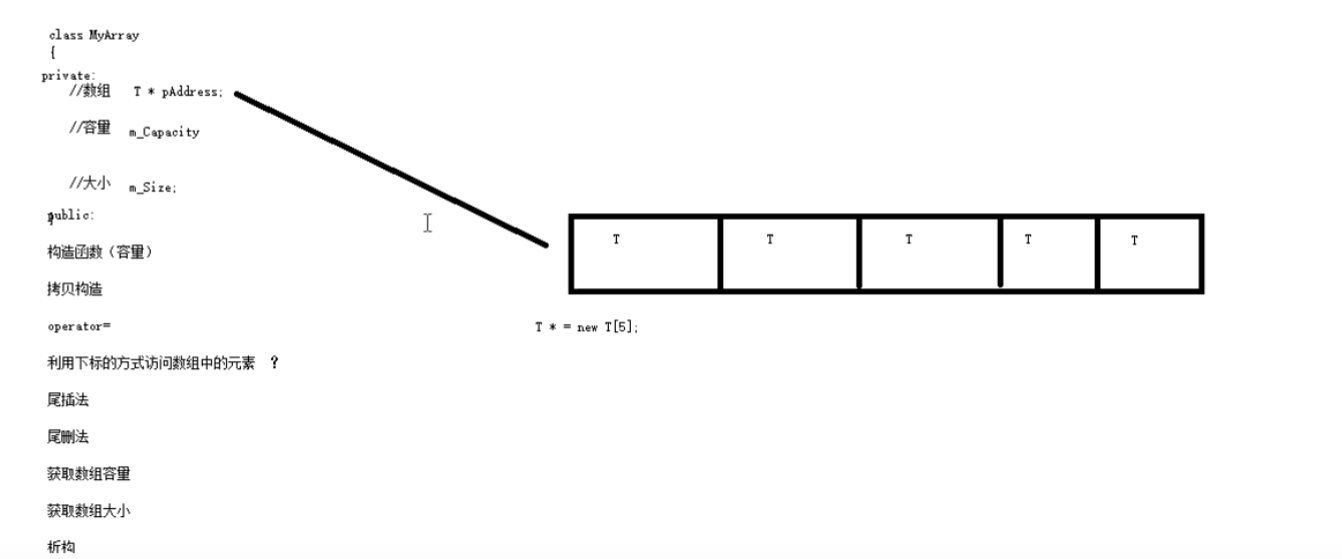

### 3.9.2 案例代码

In [ ]:
//自己的通用的数组类
#pragma once
#include <iostream>
using namespace std;
#include<string>

template<class T>
class MyArray
{
public:
    //有参构造 参数为容量
    MyArray(int capacity)
    {
        //cout << "MyArray有参构造调用" << endl;
        this->m_Capacity = capacity;
        this->m_Size = 0;
        this->pAddress = new T[this->m_Capacity]; //T[this->m_Capacity]表示类型为T的数组                                        
    }

    //拷贝构造
    MyArray(const MyArray& arr)
    {
        //cout << "MyArray拷贝构造调用" << endl;
        this->m_Capacity = arr.m_Capacity;
        this->m_Size = arr.m_Size;
        //this->pAddress = arr.pAddress; //浅拷贝会导致堆区数据重复释放

        //深拷贝
        this->pAddress = new T[arr.m_Capacity];

        //将arr中的数据都拷贝过来
        for (int i = 0; i < this->m_Size; i++)
        {
            this->pAddress[i] = arr.pAddress[i];
        }
    }

    //operator= 防止浅拷贝问题
    MyArray& operator = (const MyArray& arr)
    {
        //cout << "MyArray 的 operator调用" << endl;
        //先判断原来堆区是否有数据，如果有先释放
        if (this->pAddress != NULL)
        {
            delete[] this->pAddress;
            this->pAddress = NULL;
            this->m_Capacity = 0;
            this->m_Size = 0;
        }

        //深拷贝
        this->m_Capacity = arr.m_Capacity;
        this->m_Size = arr.m_Size;
        this->pAddress = new T[arr.m_Capacity];
        for (int i = 0; i < this->m_Size; i++)
        {
            this->pAddress[i] = arr.pAddress[i];
        }
        return *this;
    }

    //尾插法
    void Push_Back(const T& val)
    {
        //判断容量是否等于大小
        if (this->m_Capacity == this->m_Size)
        {
            return;
        }
        this->pAddress[this->m_Size] = val; //在数组末尾插入数据
        this->m_Size++; //更新数组大小
    }

    //尾删法
    void Pop_Back()
    {
        //让用户访问不到最后一个元素，即为尾删，逻辑删除
        if (this->m_Size == 0)
        {
            return;
        }
        this->m_Size--;
    }

    //通过下标方式访问数组中的元素
    //例如，还想arr[0]作为左值存在，要返回T的引用，把数据本身作为一个返回
    T& operator[](int index)
    {
        return this->pAddress[index];
    }
    
    //返回数组容量
    int getCapacity()
    {
        return this->m_Capacity;
    }

    //返回数组大小
    int getSize()
    {
        return this->m_Size;
    }

    //析构函数
    ~MyArray()
    {
        if (this->pAddress != NULL)
        {
            //cout << "MyArray析构函数调用" << endl;
            delete[] this->pAddress;
            this->pAddress = NULL;
        }
    }

private:
    T* pAddress; //指针指向堆区开辟的真实数组
    int m_Capacity; //数组容量
    int m_Size; //数组大小
};

void printIntArray(MyArray<int>& arr)
{
    for (int i = 0; i < arr.getSize(); i++)
    {
        cout << arr[i] << endl;
    }
}

void test01()
{
    MyArray<int>arr1(5);
    
    for (int i = 0; i < 5; i++)
    {
        //利用尾插法向数组中插入数据
        arr1.Push_Back(i);
    }
    cout << "arr1的打印输出为：" << endl;

    printIntArray(arr1);
    
    cout << "arr1的容量为：" << arr1.getCapacity() << endl;
    cout << "arr1的大小为：" << arr1.getSize() << endl;

    MyArray<int>arr2(arr1);

    cout << "arr2的打印输出为：" << endl;
    printIntArray(arr2);

    //尾删
    arr2.Pop_Back();
    cout << "arr2尾删后：" << endl;
    cout << "arr2的容量为：" << arr2.getCapacity() << endl;
    cout << "arr2的容量为：" << arr2.getSize() << endl;

    MyArray<int>arr3(100);
    arr3 = arr1;
}

//测试自定义数据类型
class Person
{
public:
    Person() {}; //默认构造空实现
    Person(string name, int age)
    {
        this->m_Name = name;
        this->m_Age = age;
    }

    string m_Name;
    int m_Age;
};

void printPersonArray(MyArray<Person>& arr)
{
    for (int i = 0; i < arr.getSize(); i++)
    {
        cout << "姓名：" << arr[i].m_Name << "年龄：" << arr[i].m_Age << endl;
    }
}

void test02()
{
    MyArray<Person> arr(10);

    Person p1("孙悟空", 999);
    Person p2("韩信", 30);
    Person p3("妲己", 20);
    Person p4("赵云", 25);
    Person p5("安其拉", 27);

    //将数据插入到数组中
    arr.Push_Back(p1);
    arr.Push_Back(p2);
    arr.Push_Back(p3);
    arr.Push_Back(p4);
    arr.Push_Back(p5);

    //打印数组
    printPersonArray(arr);

    //输出容量
    cout << "arr的容量为：" << arr.getCapacity() << endl;

    //输出大小
    cout << "arr的大小为：" << arr.getSize() << endl;
}

int main() {

    test01();
    test02();

    system("pause");

    return 0;
}

运行结果：  
- arr1的打印输出为：  
- 0  
- 1  
- 2  
- 3  
- 4  
- arr1的容量为：5  
- arr1的大小为：5  
- arr2的打印输出为：  
- 0  
- 1  
- 2  
- 3  
- 4  
- arr2尾删后：  
- arr2的容量为：5  
- arr2的容量为：4  
- 姓名：孙悟空年龄：999  
- 姓名：韩信年龄：30  
- 姓名：妲己年龄：20  
- 姓名：赵云年龄：25  
- 姓名：安其拉年龄：27  
- arr的容量为：10  
- arr的大小为：5  
- 请按任意键继续. . .

# 4. 模板局限性

## 4.1 模板局限性简介

① 模板的通用性并不是万能的。

② 利用具体化的模板，可以解决自定义类型的通用化。

③ 学习模板并不是为了写模板，而是在STL中能够运用系统提供的模板。

## 4.2 局限性一

In [ ]:
//下面代码提供赋值操作，如果传入的a和b是一个数组，就无法实现了
//数组无法给另一个数组直接赋值

template<class T>
void myPrint(T a, T b)
{
    a = b;
}

## 4.3 局限性二

In [ ]:
//在下面代码中，如果T的数据类型传入的是像Person这样的自定义数据类型，也无法正常运行。

template<class T>
void myPrint(T a, T b)
{
    if (a > b) { ... };
}

## 4.4 模板具体实现

In [ ]:
#include <iostream>
using namespace std;
#include<string>

//模板局限性
//模板并不是万能的，有些特定数据类型，需要用具体化方式做特殊实现

class Person
{
public:
    Person(string name, int age)
    {
        this->m_Name = name;
        this->m_Age = age;
    }
    string m_Name;
    int m_Age;
};

//对比两个数据是否相等的函数
template<class T>
bool myCompare(T &a, T &b)
{
    if (a == b) //(a == b)能判断整型、浮点型数据是否相等，但是没有办法判断Person类型与Person类型相等比较，但是可以通过==运算符重载，来判断Person类型的p1和Person类型的p2是否相等
    {
        return true;
    }
    else
    {
        return false;
    }
}

//利用具体化的Person(类)版本实现代码，具体化优先调用
template<> bool myCompare(Person & p1, Person & p2) //template<>表示这是一个模板重载的版本，Person表示这是重载的person的模板    
{
    if (p1.m_Name == p2.m_Name && p1.m_Age == p2.m_Age)
    {
        return true;
    }·
    else
    {
        return false;
    }
}

void test01()
{
    int a = 10;
    int b = 20;
    
    bool ret = myCompare(a, b);

    if (ret)
    {
        cout << "a==b" << endl;
    }
    else
    {
        cout << "a!=b" << endl;
    }
}

void test02()
{
    Person p1("Tom", 10);
    Person p2("Tom", 10);

    bool ret = myCompare(p1, p2);
    if (ret)
    {
        cout << "p1==p2" << endl;
    }
    else
    {
        cout << "p1!=p2" << endl;
    }
}

int main()
{
    test01();
    test02();

    system("pause");

    return 0;
}

运行结果：  
- a!=b  
- p1==p2  
- 请按任意键继续. . .